# Stacking For Classification with Python

Estimated time needed: **45** minutes

## Objectives

After completing this lab you will be able to:

*   **Understand** what Stacking is and how it works
*   **Understand**  that Random Forests have less Correlation between predictors in their ensemble, improving accuracy
*   **Apply** Stacking
*   **Understand** Hyperparameters selection in  Stacking


Stacking takes several classification models called base learners and uses their output as the input for the meta-classifier. Consider the figure below the base learners $h_{1}(x)$, $h_{2}(x)$, $h_{3}(x)$, and $h_{4}(x)$ has the output $\hat{y}_{1}$, $\hat{y}_{2}$, $\hat{y}_{3}$, $\hat{y}_{4}$. These are used as an input to the meta classifier $H( \hat{y}_{1}, \hat{y}_{2}, \hat{y}_{3}, \hat{y}_{4})$, makes the final prediction $\hat{y}=H( \hat{y}_{1}, \hat{y}_{2}, \hat{y}_{3}, \hat{y}_{4})$.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/module5_Ensemble_Based_Methods/Screen_Shot_2022-01-12_at_9.40.33_PM.png" width="1000" alt="cognitiveclass.ai logo">
</center>
<center>Fig. 1 Stacking takes several classification models called base learners and uses their output as the input for the meta-classifier. </center>


We can train all the models using all the data but this causes over-fitting. To get a better idea of how the algorithm works we use K-fold Cross-validation. We use K-1 folds to train the base classifiers and the last fold to train the meta classifier. We repeat the process using different combinations of each fold. This is shown in Fig 2 where the color-coded square represents the different runs and folds. Each row represents a different run of K fold cross-validation, each column is one of K folds where K=3. For each column, we use the same color columns to train the classifiers and the different color is used to train the meta classifier.


<center>
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/module5_Ensemble_Based_Methods/stacking-kfold.png" width="1000" alt="cognitiveclass.ai logo">
</center>
<center>Fig. 2  K-fold Cross-validation to train Stacking classifier. </center>


<h1>Table of contents</h1>

<div class="" style="margin-top: 20px">
    <ol>
        <li>Apply Stacking Using Wine Data</li>
        <li>Practice</li>
        <li>Cancer Data Example</li>
    </ol>
</div>
<br>
<hr>


First, let's install and import the required libraries:


In [1]:
import pandas as pd
import numpy as np
import scipy.optimize as opt
from sklearn import preprocessing
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn import preprocessing
from sklearn.ensemble import StackingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

This function will calculate the accuracy of the training and testing data given a model.


In [2]:
def get_accuracy(X_train, X_test, y_train, y_test, model):
    return  {"test Accuracy":metrics.accuracy_score(y_test, model.predict(X_test)),"train Accuracy": metrics.accuracy_score(y_train, model.predict(X_train))}

<h1>Apply   Stacking Using   Wine Data  </h1>

The class is an essential factor in determining the quality of the wine; this dataset uses chemical analysis of wines grown in the same region in Italy from three different cultivars. Your task is to determine the class  of the wine using the features from the chemical analysis.
The features or attributes include

<pre>
1) Alcohol
2) Malic acid
3) Ash
4) Alcalinity of ash
5) Magnesium
6) Total phenols
7) Flavanoids
8) Nonflavanoid phenols
9) Proanthocyanins
10) Color intensity
11) Hue
12) OD280/OD315 of diluted wines
13) Proline
</pre>

For more info <a href="https://archive.ics.uci.edu/ml/datasets/wine?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2022-01-01">here </a>,let's load the dataset:


In [3]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/wine.data"

df = pd.read_csv("data/wine.data",names= ['Class', 'Alcohol', 'Malic acid', 'Ash', 'Alcalinity of ash' ,'Magnesium', 'Total phenols',
         'Flavanoids', 'Nonflavanoid phenols', 'Proanthocyanins',     'Color intensity', 'Hue', 'OD280/OD315 of diluted wines',
         'Proline'])

df.head()

,Class,Alcohol,Malic acid,Ash,Alcalinity of ash,Magnesium,Total phenols,Flavanoids,Nonflavanoid phenols,Proanthocyanins,Color intensity,Hue,OD280/OD315 of diluted wines,Proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735


We see all the dataset is comprised of numerical values using the method <code>dtypes</code>


In [4]:
df.dtypes

Class                             int64
Alcohol                         float64
Malic acid                      float64
Ash                             float64
Alcalinity of ash               float64
Magnesium                         int64
Total phenols                   float64
Flavanoids                      float64
Nonflavanoid phenols            float64
Proanthocyanins                 float64
Color intensity                 float64
Hue                             float64
OD280/OD315 of diluted wines    float64
Proline                           int64
dtype: object

the column <code>class</code> has the class of the wine, we can use the method <code>unique()</code> to obtain the classes:


In [5]:
df['Class'].unique()

array([1, 2, 3])

We can examine the correlation between each feature and the class variable. By examining the first row or column we see the features are correlated with the class variable.


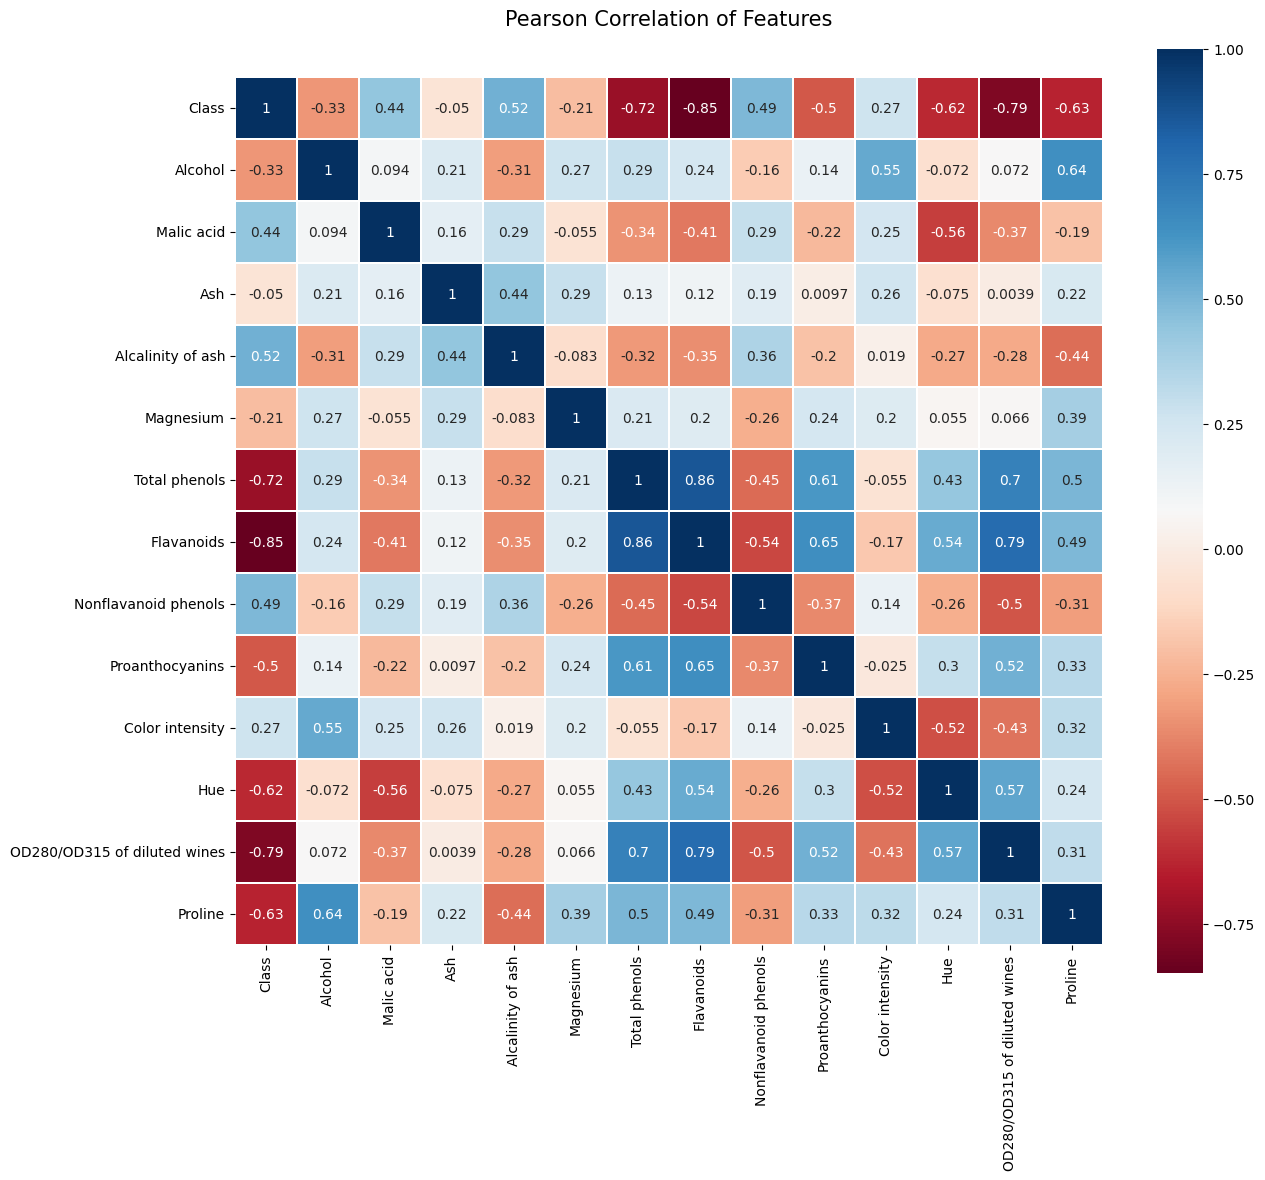

In [6]:
colormap = plt.cm.RdBu
plt.figure(figsize=(14,12))
plt.title('Pearson Correlation of Features', y=1.05, size=15)
sns.heatmap(df.astype(float).corr(),linewidths=0.1,vmax=1.0, 
            square=True, cmap=colormap, linecolor='white', annot=True)
plt.show()

We can also examine the <code>Pairplot</code> between pairs of features and the histogram; color-coded to each class. We see the separation between different classes:


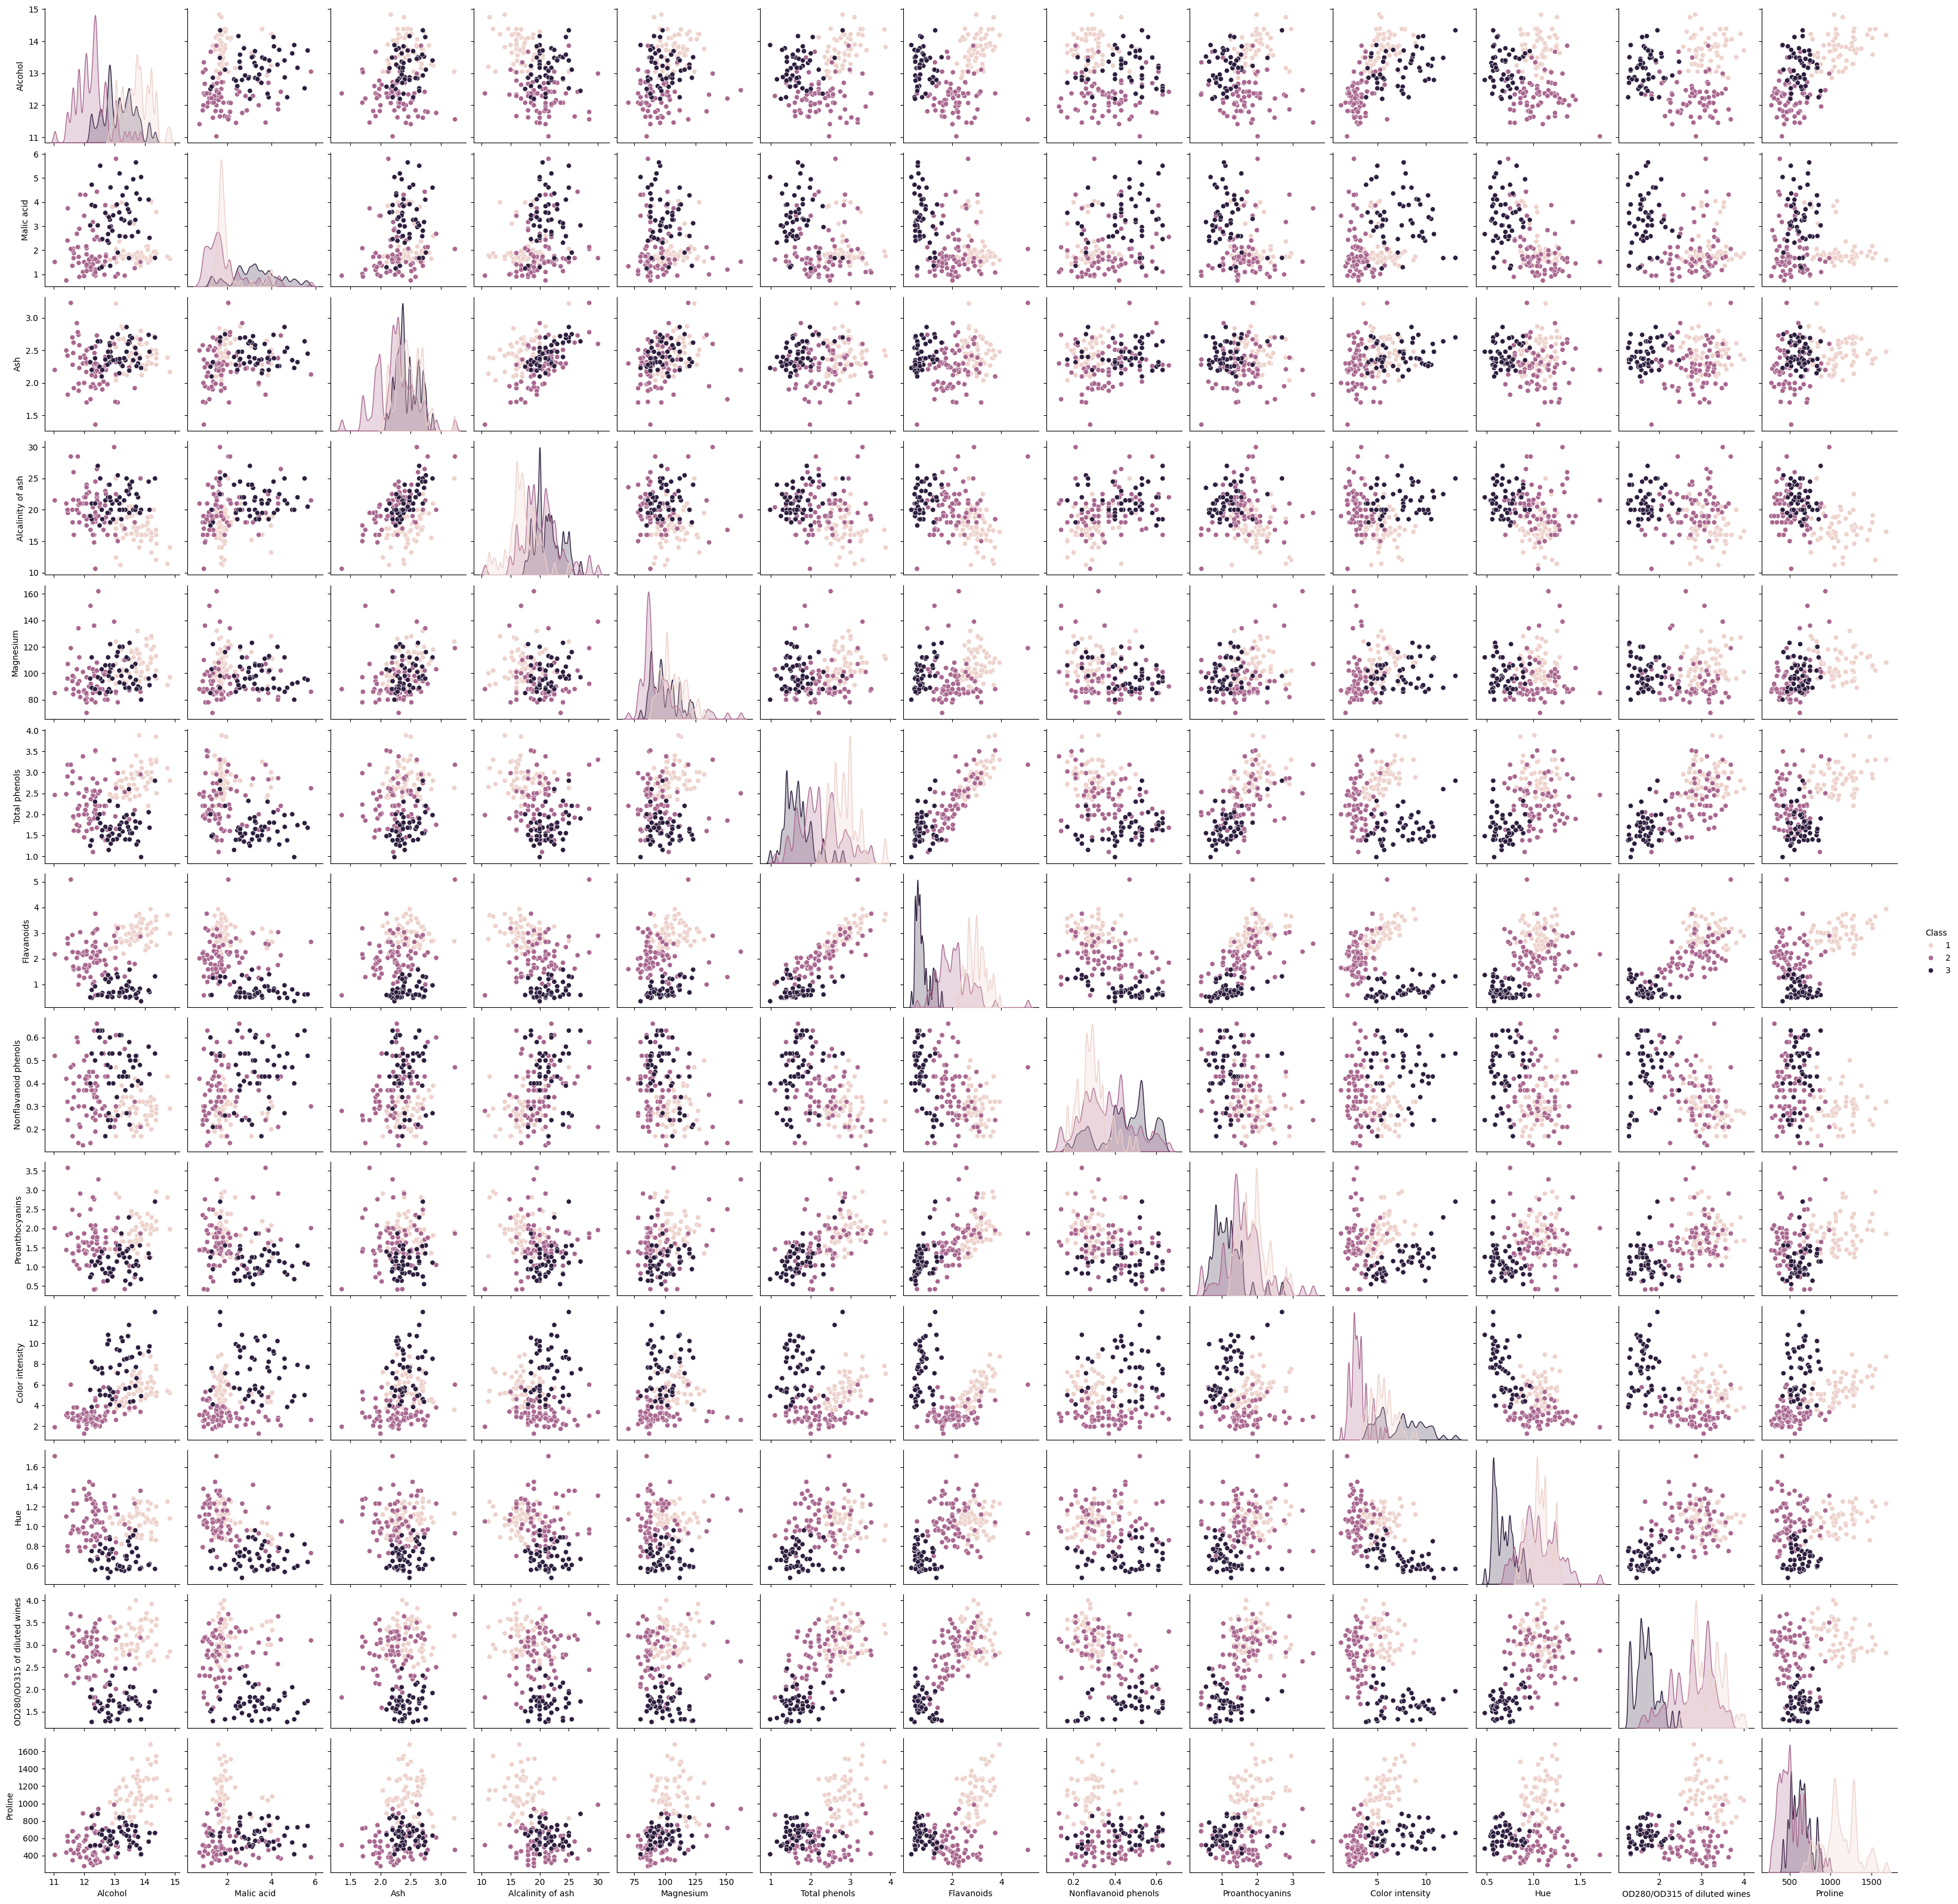

In [7]:
# May need to specify bandwidth (bw) in order to plot, else can delete the `, diag_kws={'bw': 0.2})` code.
sns.pairplot(df, hue="Class", diag_kws={'bw_adjust': 0.2})

### Data Pre-Processing and Selection


Let’s examine the feature list


In [8]:
features=list(df)
features[1:]

['Alcohol',
 'Malic acid',
 'Ash',
 'Alcalinity of ash',
 'Magnesium',
 'Total phenols',
 'Flavanoids',
 'Nonflavanoid phenols',
 'Proanthocyanins',
 'Color intensity',
 'Hue',
 'OD280/OD315 of diluted wines',
 'Proline']

We assign the class variables to <code>y</code> and feature variables to <code>X</code>


In [9]:
y,X=df[features[0]] ,df[features[1:]]

We can standardize the data


In [10]:
scaler = preprocessing.StandardScaler().fit(X)
X= scaler.transform(X)

We can check if the data is standardized by checking the mean and standard deviation, which are approximately zero:


In [11]:
X.mean(axis=0)

array([-8.38280756e-16, -1.19754394e-16, -8.37033314e-16, -3.99181312e-17,
       -3.99181312e-17,  0.00000000e+00, -3.99181312e-16,  3.59263181e-16,
       -1.19754394e-16,  2.49488320e-17,  1.99590656e-16,  3.19345050e-16,
       -1.59672525e-16])

In [12]:
X.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

In Random Forest, we would use these data subsets to train each node of a tree.


### Train/Test dataset


We split our dataset into train and test set:


In [13]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=1)
print ('Train set', X_train.shape,  y_train.shape)
print ('Test set', X_test.shape,  y_test.shape)

Train set (124, 13) (124,)
Test set (54, 13) (54,)


Stacking consists of creating a Stacking Classifier object, but first, you require a dictionary of <code>estimators</code> (individual model objects or base learners). The key of the dictionary is a name that is up to you, we use the usual acronym for the model. The value is the model object in this case SVC for Support Vector Classifier, dt for Decision Tree Classifier and KNN for K Neighbors Classifier.


In [14]:
estimators = [('SVM',SVC(random_state=42)), ('KNN',KNeighborsClassifier()), ('dt',DecisionTreeClassifier())]
estimators

[('SVM', SVC(random_state=42)),
 ('KNN', KNeighborsClassifier()),
 ('dt', DecisionTreeClassifier())]

To train the final model we create a Stacking Classifier, this combines the base estimators using the meta estimator. The meta-classifier is determined by the parameter <code>final_estimator</code> in this case we use Logistic Regression, we also input the base classifiers using the <code>estimators</code> parameter and fit the model.


In [15]:
clf = StackingClassifier( estimators=estimators, final_estimator= LogisticRegression())
clf.fit(X_train, y_train)
clf

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('SVM', ...), ('KNN', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegression()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degre

We can make a prediction


In [16]:
yhat=clf.predict(X_test)
yhat

array([3, 2, 1, 2, 1, 3, 2, 1, 3, 2, 1, 1, 2, 1, 2, 2, 3, 1, 2, 1, 1, 2,
       2, 2, 1, 3, 1, 1, 1, 3, 2, 3, 3, 1, 2, 2, 2, 2, 2, 1, 1, 2, 3, 1,
       1, 1, 2, 1, 1, 1, 2, 3, 3, 1])

We can obtain the training and testing accuracy, we see the model performs well.


In [17]:
get_accuracy(X_train, X_test, y_train, y_test, clf)

{'test Accuracy': 0.9814814814814815, 'train Accuracy': 1.0}

<div style="color:red">


<div style="color:red">
   <b> Note: Like most complex models Stacking is prone to overfitting because it introduces a hierarchical architecture where models learn from the predictions of other models.</b>
</div>

### Why is Stacking prone to overfitting?
Stacking is highly vulnerable to overfitting because it introduces a hierarchical architecture where models learn from the predictions of other models.

In a standard machine learning setup, a model looks at the raw features ($X$) to predict the target ($y$). In Stacking, we introduce a second layer — the Meta-Model — whose entire job is to look at the predictions made by the Layer 1 models and figure out how to combine them.This multi-layered setup creates two major structural flaws that invite overfitting:

1. **Information Leakage (The "Cheat Sheet" Effect)**

   If we train our Layer 1 models on the exact same training dataset that we use to train the Meta-Model, disaster strikes.

   Because the Layer 1 models have already memorized portions of the training data, their predictions on that data will be unrealistically perfect. When the Meta-Model looks at these perfect predictions, it thinks, "Wow, Model A is a genius! I will always trust Model A."

   However, when we finally introduce completely unseen test data, the Layer 1 models will make normal, imperfect predictions. The Meta-Model, having never learned how to handle Layer 1 errors, will blindly trust those flawed predictions, causing its performance to collapse.


2. **Compounding Model Complexity**

   Every time we add a new base learner to our Stacking pipeline, we increase the overall capacity of the system to memorize noise.

   If we stack an XGBoost model, a Support Vector Machine, and a Random Forest together, we aren't just getting their strengths; we are giving a powerful Meta-Model a highly complex feature space (the combination of all their output probabilities) to twist and bend. A sufficiently complex Meta-Model can easily find accidental, spurious correlations between the base models' mistakes and the target variable that only exist in that specific training set.


### How Data Scientists Fight Stacking Overfitting

To use Stacking safely without it blowing up on our test data, we must implement defensive engineering:

1. **Out-of-Fold Predictions (Stacking Cross-Validation)**

   We should never let the Meta-Model see predictions from models that were trained on those same rows. Data scientists use K-Fold Cross-Validation to generate Out-of-Fold (OOF) predictions.

   * Divide the training data into 5 folds.

   * Train Layer 1 models on Folds 1–4, and make predictions on the unseen Fold 5.

   * Repeat this so that every row in the dataset gets predicted by a model that never saw that row during training.

   * Feed only these OOF predictions to the Meta-Model. This mimics true, unseen test data.

2. **Keep the Meta-Model Simple**

   Because the input features to the Meta-Model are already highly refined predictions, the Meta-Model itself doesn't need to be complex. Passing the predictions into another massive, deep Random Forest or XGBoost wrapper is an open invitation to overfit. Instead, the standard practice is to use a heavily constrained, simple model—like a Linear Regression (for regression tasks) or a Logistic Regression (for classification) as the final manager.

<BR><BR>

<h1>Practice</h1>


Create a Stacking Classifier object as before but exchange the Decision Tree Classifier with the SVM classifier. Calculate the accuracy on the training and testing data.


In [18]:
estimators = [('SVM',SVC(random_state=42)), ('KNN',KNeighborsClassifier()), ('lr',LogisticRegression())]
clf = StackingClassifier( estimators=estimators, final_estimator=LogisticRegression())
clf.fit(X_train, y_train)

get_accuracy(X_train, X_test, y_train, y_test, clf) 

{'test Accuracy': 0.9814814814814815, 'train Accuracy': 1.0}

The identical result shows how dominant one or two of the base models are over the final decision pipeline.

There are two major reasons why the StackingClassifier is outputting the identical accuracy metrics across both architectures:

1. The "Dominant Expert" Effect (SVM or KNN are carrying the team)

    In a StackingClassifier, the final meta-model (LogisticRegression) assigns mathematical weights (coefficients) to the predictions of each base learner. If one or two base models are already performing exceptionally well on the dataset, the meta-model learns to heavily favor them and essentially ignores the third model.

    * In the previous setup, the SVM and KNN might be perfectly mapping the classification boundaries. The meta-model looks at the Decision Tree, realizes its predictions don't add any new value, and assigns its coefficient a weight close to zero.

    * In the above second setup, we swap the tree for a Logistic Regression. The meta-model looks at it, still finds it redundant compared to the SVM/KNN combo, and also zeroes its influence out.

    Because the meta-model is relying on the exact same dominant models (SVM and KNN) to make its final decisions in both runs, the final predictions — and therefore the accuracy scores—remain entirely unchanged.

2. A Clean, Linearly Separable Dataset

    Given that the training accuracy is 1.0 (100%) and the test accuracy is a massive 98.15%, the dataset is highly structured and remarkably easy for these algorithms to solve.

    When a dataset has strong, clear signals, different combinations of high-performing models will often arrive at the exact same classification boundaries for the test set. There are only a tiny handful of "edge-case" samples being misclassified (the missing 1.85%). Swapping out a weak third model isn't enough structural disruption to fix or alter those specific, tricky edge cases.

#### How to Prove This Under the Hood

We can pull back the curtain and see exactly how the meta-model is treating the algorithms by inspecting its internal weights. We can run the following code snippet right after fitting each of our stacking classifiers:

In [19]:
# First Setup
estimators = [('SVM',SVC(random_state=42)), ('KNN',KNeighborsClassifier()), ('dt',DecisionTreeClassifier())]
clf = StackingClassifier( estimators=estimators, final_estimator= LogisticRegression())
clf.fit(X_train, y_train)

# Print the weights assigned to each base model by the final Logistic Regression manager
for name, coef in zip(clf.named_estimators_.keys(), clf.final_estimator_.coef_[0]):
    print(f"Base Model: {name} | Meta-Model Weight: {coef:.4f}")

Base Model: SVM | Meta-Model Weight: 1.1913
Base Model: KNN | Meta-Model Weight: -0.6983
Base Model: dt | Meta-Model Weight: -0.4746


In [20]:
# Second Setup
estimators = [('SVM',SVC(random_state=42)), ('KNN',KNeighborsClassifier()), ('lr',LogisticRegression())]
clf = StackingClassifier( estimators=estimators, final_estimator=LogisticRegression())
clf.fit(X_train, y_train)

# Print the weights assigned to each base model by the final Logistic Regression manager
for name, coef in zip(clf.named_estimators_.keys(), clf.final_estimator_.coef_[0]):
    print(f"Base Model: {name} | Meta-Model Weight: {coef:.4f}")

Base Model: SVM | Meta-Model Weight: 1.0864
Base Model: KNN | Meta-Model Weight: -0.5263
Base Model: lr | Meta-Model Weight: -0.5249


From the above results, we can see that the weights for SVM remain large and stable across both runs, while the weight assigned to the second, and third slot (dt vs lr) is  completely overridden by the dominant SVM!

#### What if we use DecisionTree as the final_estimator for the second setup?

Here is exactly what changes under the hood when we make a Decision Tree the boss of the stack:

1. From Smooth Blending to Sharp Thresholds

    A LogisticRegression meta-model acts like a flexible, diplomatic manager. It assigns smooth, continuous weights to each model's predictions. If SVM is 80% sure it's Class A, and KNN is 60% sure it's Class B, the Logistic Regression can mathematically balance those probabilities to find a compromise.
    
    A DecisionTreeClassifier meta-model, on the other hand, acts like a rigid bureaucrat making a checklist. It creates hard, binary splits on the base models' outputs. It will create strict rules like:
    * If SVM's prediction probability for Class 1 is $> 0.53$, choose Class 1.
    * Otherwise, if KNN's prediction probability is $\le 0.21$, check the Logistic Regression base learner.
    
    Instead of blending the strengths of the models, the final decision boundary becomes boxy and jagged.
    
2. High Vulnerability to Meta-Overfitting

    As discussed earlier, Stacking is naturally prone to overfitting. Passing the base predictions into a Decision Tree manager amplifies this risk dramatically.
    
    Because a Decision Tree loves to split the data until it achieves absolute purity, it will easily memorize the tiny quirks, flukes, and accidental trends in how the base estimators misclassified rows during the internal cross-validation phase. It will build a highly intricate, overfitted tree structure just to get that training score to a perfect 1.0, but it will lack the smooth generalizability needed to handle the test set cleanly.

The following codes demonstrates the result output:

In [21]:
# if we use a raw DecisionTreeClassifier() without limiting it, it will likely overfit. 
# Here we restrict it using something like max_depth=3, to force it to behave more like a simple "voting logic" controller, which might preserve our high test accuracy!

estimators = [('SVM',SVC(random_state=42)), ('KNN',KNeighborsClassifier()), ('lr',LogisticRegression())]
clf = StackingClassifier( estimators=estimators, final_estimator=DecisionTreeClassifier(max_depth=3))
clf.fit(X_train, y_train)

get_accuracy(X_train, X_test, y_train, y_test, clf)

{'test Accuracy': 0.9814814814814815, 'train Accuracy': 0.9919354838709677}

The test accuracy held exactly at 0.9814814814814815, but the training accuracy dropped slightly from a perfect 1.0 down to 0.991935.

This is actually a beautiful textbook example of intentional regularization at work, and it proves exactly what we were anticipating.
The Breakdown of What Just Happened

1. The Test Accuracy is a Mirror: 
    The fact that your test accuracy didn't budge at all tells us that the core, high-performing base models (SVM and KNN) are producing incredibly clean, stable predictions. The final decision boundaries for those test samples are so robust that whether the manager uses a line (LogisticRegression) or a short tree (DecisionTreeClassifier(max_depth=3)), the resulting classifications come out identical.

2. The Train Accuracy Dropped (And that's a good thing!): 
    When the training accuracy was 1.0, the previous models were completely memorizing the training dataset. By restricting the tree to max_depth=3, we stripped away its ability to create hyper-specific, microscopic rules to capture the final 0.8% of noise or weird edge cases in the training data. We forced the tree to only focus on the 3 most important structural rules.


#### How to See the "Rules" the Boss is Using

Because the meta-model is now a shallow Decision Tree, we have a massive advantage: it is 100% visual and interpretable. We can actually print out the exact checklist the manager tree is using to make decisions using the following codes:

In [22]:
from sklearn.tree import export_text

# 1. Grab the names of your base models
base_names = list(clf.named_estimators_.keys())  # ['SVM', 'KNN', 'lr']

# 2. Grab the actual class labels from the model (e.g., ['DrugY', 'drugX', ...])
class_labels = clf.classes_

# 3. Auto-generate the 9 meta-feature names to match scikit-learn's internal matrix
meta_feature_names = [
    f"{model_name}_prob_{cls}" for model_name in base_names for cls in class_labels
]

# 4. Print the rules safely!
print(export_text(clf.final_estimator_, feature_names=meta_feature_names))

|--- SVM_prob_2 <= 2.17
|   |--- KNN_prob_1 <= 0.60
|   |   |--- lr_prob_3 <= 0.76
|   |   |   |--- class: 1
|   |   |--- lr_prob_3 >  0.76
|   |   |   |--- class: 2
|   |--- KNN_prob_1 >  0.60
|   |   |--- class: 0
|--- SVM_prob_2 >  2.17
|   |--- class: 1



The above printout gives us the absolute mathematical proof of exactly why our accuracy didn't change earlier.

Look closely at the features the Decision Tree manager chose to split on: out of all 9 possible probability columns across 3 different models, it almost completely relies on the SVM.

Here is the exact breakdown of the logic the manager tree built:

**The Executive Logic Breakdown**

1. The Primary Rule: The tree's very first split (the root) is on SVM_prob_2. If that probability value is high ($> 2.17$), it immediately stops looking and declares the answer is Class 1.

2. The Secondary Rule: If SVM_prob_2 is low ($\le 2.17$), it moves down to check SVM_prob_3. If that is exceptionally low ($\le -0.15$), it calls it Class 0.

3. The Tie-Breaker: Only in the remaining middle ground does it check a second model, looking at lr_prob_2 to choose between Class 2 and Class 1.

Notice what is completely missing? KNN isn't even mentioned in the tree. The Decision Tree manager looked at the predictions from KNN and deemed them completely redundant or unnecessary to achieve its 99.19% training accuracy.

**Why are there negative probability values?**

True probabilities are strictly bounded between $0$ and $1$, so how can an SVM output a negative number or a number greater than 2?

This reveals another hidden inner working of scikit-learn's stacking engine:

By default, if the base estimator is an SVC (Support Vector Machine) and we haven't explicitly turned on probability tracking (probability=True), it cannot output true percentage probabilities.

Instead, the StackingClassifier automatically falls back to grabbing the raw Decision Function values from the SVM. The decision function outputs raw, un-bounded distance scores (how many standard deviations a data point is from the separating hyperplane).

* A negative value means it's far on the "negative" side of the boundary.

* A value like $2.17$ means it is deep into the "positive" side of the boundary.

<BR><BR>

___

<h1> GridSearchCV and Stacking Classifiers  </h1>


Imagine that you are a medical researcher compiling data for a study. You have collected data about a set of patients, all of whom suffered from the same illness. During their course of treatment, each patient responded to one of 5 medications, Drug A, Drug B, Drug c, Drug x and y.

Part of your job is to build a model to find out which drug might be appropriate for a future patient with the same illness. The features of this dataset are Age, Sex, Blood Pressure, and the Cholesterol of the patients, and the target is the drug that each patient responded to.

It is a sample of multiclass classifier, and you can use the training part of the dataset to build a decision tree, and then use it to predict the class of a unknown patient, or to prescribe a drug to a new patient. You will use GridSearchCV and Stacking Classifiers  to find the best results.


In [23]:
# data_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%203/data/drug200.csv"

df = pd.read_csv("data/drug200.csv", delimiter=",")
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


Let's create the X and y for our dataset:


In [24]:
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].values
X[0:5]

array([[23, 'F', 'HIGH', 'HIGH', 25.355],
       [47, 'M', 'LOW', 'HIGH', 13.093],
       [47, 'M', 'LOW', 'HIGH', 10.114],
       [28, 'F', 'NORMAL', 'HIGH', 7.798],
       [61, 'F', 'LOW', 'HIGH', 18.043]], dtype=object)

In [25]:
y = df["Drug"]
y[0:5]

0    drugY
1    drugC
2    drugC
3    drugX
4    drugY
Name: Drug, dtype: str

Now lets use a <code>LabelEncoder</code> to turn categorical features into numerical:


In [26]:
from sklearn import preprocessing
le_sex = preprocessing.LabelEncoder()
le_sex.fit(['F','M'])
X[:,1] = le_sex.transform(X[:,1]) 


le_BP = preprocessing.LabelEncoder()
le_BP.fit([ 'LOW', 'NORMAL', 'HIGH'])
X[:,2] = le_BP.transform(X[:,2])


le_Chol = preprocessing.LabelEncoder()
le_Chol.fit([ 'NORMAL', 'HIGH'])
X[:,3] = le_Chol.transform(X[:,3]) 

X[0:5]

array([[23, 0, 0, 0, 25.355],
       [47, 1, 1, 0, 13.093],
       [47, 1, 1, 0, 10.114],
       [28, 0, 2, 0, 7.798],
       [61, 0, 1, 0, 18.043]], dtype=object)

In [27]:
scaler = preprocessing.StandardScaler().fit(X)
X= scaler.transform(X)

Split the data into training and testing data with a 80/20 split


In [28]:
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.3, random_state=4)
print ('Train set:', X_train.shape,  y_train.shape)
print ('Test set:', X_test.shape,  y_test.shape)

Train set: (140, 5) (140,)
Test set: (60, 5) (60,)


We have our dictionary of estimators, the individual model objects or base learners.


In [29]:
estimators = [('SVM',SVC(random_state=42)),('knn',KNeighborsClassifier()),('dt',DecisionTreeClassifier())]
estimators

[('SVM', SVC(random_state=42)),
 ('knn', KNeighborsClassifier()),
 ('dt', DecisionTreeClassifier())]

We create a Stacking Classifier:


In [30]:
clf = StackingClassifier( 
                            estimators = estimators, 
                            final_estimator = LogisticRegression(max_iter=1000, random_state=42)  # Set max_iter=1000 to stop ConvergenceWarning
                        )
clf

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('SVM', ...), ('knn', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",LogisticRegre...ndom_state=42)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",None
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"de

In order to alter the base models in the dictionary of hyperparameter values, we add the key value of each model followed by the parameter of the model we would like to vary.


In [31]:
param_grid = {
    'dt__max_depth'     : list(range(1, 10)),
    'dt__random_state'  : [0],
    'SVM__C'            : [0.01,0.1,1],
    'SVM__kernel'       : ['linear', 'poly', 'rbf'],
    'knn__n_neighbors'  : [1,4,8,9] 
    }


We use <code>GridSearchCV</code> to search over specified parameter values of the model.


In [32]:
search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy')
search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",StackingClass...dom_state=42))
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'SVM__C': [0.01, 0.1, ...], 'SVM__kernel': ['linear', 'poly', ...], 'dt__max_depth': [1, 2, ...], 'dt__random_state': [0], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fo

We can find the accuracy of the best model.


In [33]:
search.best_score_

np.float64(1.0)

We can find the best parameter values:


In [34]:
search.best_params_

{'SVM__C': 0.01,
 'SVM__kernel': 'linear',
 'dt__max_depth': 4,
 'dt__random_state': 0,
 'knn__n_neighbors': 1}

The above parameters tell a fascinating story about what's happening under the hood!

Look at that combination:

* knn__n_neighbors: 1
* SVM__C: 0.01 (heavy regularization on a linear kernel)
* dt__max_depth: 4

#### What GridSearchCV is actually telling us

This hyperparameter set highlights the power (and quirks) of stacking on a dataset like drug200:

1. knn=1 is supplying hyper-local structure: Normally, $k=1$ is notoriously prone to overfitting on raw data because it creates micro-boundaries around single points. But in a Stacking setup, $k=1$ acts as an ultra-sensitive "nearest neighbor signal" that the meta-model can use alongside the other estimators.

2. SVM C=0.01 is heavily smoothing the SVM: Because $C=0.01$ forces a very wide, forgiving margin, the linear SVM isn't trying to overfit to individual points. It's providing a broad, linear global trend to balance out the hyper-local $k=1$ KNN predictions!

3. The Decision Tree at depth 4 handles non-linear edge cases: A depth of 4 gives the tree just enough flexibility to slice up feature combinations (like Na_to_K ratio vs. Age) without getting too deep.

The meta-model (LogisticRegression) then takes these three vastly different perspectives—a broad global line (SVM), a hyper-local neighbor score (KNN), and a rule-based logic tree (DT)—and blends them into an optimal ensemble.


We can find the accuracy test data:


In [35]:
get_accuracy(X_train, X_test, y_train, y_test, search)

{'test Accuracy': 0.9666666666666667, 'train Accuracy': 1.0}

#### What Caused the Overfit?

The main culprit in this tuned parameter grid is knn__n_neighbors: 1.

With $k=1$, the KNN base estimator memorizes its training points with zero margin for error, achieving a perfect score on the training set. Even with the smoothed linear SVM ($C=0.01$) trying to regulate the stack, that rigid $k=1$ signal pushed the entire ensemble to memorize the training data completely.

On a small test set like drug200 ($N_{test} = 60$), the difference between 0.9815 and 0.9667 is literally a single misclassified sample (58 correct vs 59 correct out of 60).

Because GridSearchCV evaluated accuracy across 3 cross-validation folds on the training split, it selected $k=1$ because it maximized the CV training folds. However, $k=1$ slightly overfit the training boundary and lost 1 sample on the unseen holdout test set.

If we bump knn__n_neighbors back up to $4$ or $8$ manually, the training score will drop slightly off 1.0, and we'll likely reclaim that missing test sample!

But if $k=4$ or $k=8$ yields a higher test score on our holdout set, why didn't GridSearchCV pick it?

The short answer is data leakage protection. GridSearchCV literally does not know the holdout test set (X_test) exists. It evaluates combinations based only on the cross-validation splits of the training set (X_train).

This is why experienced data scientists don't rely purely on search.best_params_ when a hyperparameter is known to cause overfitting (like $k=1$ or unlimited tree depth).

To prevent GridSearchCV from picking overfitted models, we have two options:

1. Constrain the grid: Remove $k=1$ from the param_grid entirely (e.g., 'knn__n_neighbors': [3, 5, 7, 9]) to force GridSearchCV to choose from smoother, more generalizable options.

2. Optimize for a metric that penalizes complexity: Use cross-validated log-loss or bounded hyperparameter constraints rather than raw accuracy alone.


We can prune $k=1$ out of the grid and run GridSearchCV again:

In [36]:
param_grid = {
    'dt__max_depth'     : list(range(1, 10)), # 1 to 9
    'dt__random_state'  : [0],
    'SVM__C'            : [0.01,0.1,1],
    'SVM__kernel'       : ['linear', 'poly', 'rbf'],
    'knn__n_neighbors'  : [4,8,9] 
    }

search = GridSearchCV(estimator=clf, param_grid=param_grid, scoring='accuracy')
search.fit(X_train, y_train)
search.best_params_

{'SVM__C': 0.01,
 'SVM__kernel': 'linear',
 'dt__max_depth': 4,
 'dt__random_state': 0,
 'knn__n_neighbors': 4}

And what the accuracy metrics on X_train and X_test end up looking like with $k=4$?

In [37]:
get_accuracy(X_train, X_test, y_train, y_test, search)

{'test Accuracy': 0.9666666666666667, 'train Accuracy': 1.0}

Even with $k=4$, the overall stack is still powerful enough to achieve 100% training accuracy while making that single misclassification on the test set.

What This Tells Us About the drug200 Dataset:

1. The Train/Test Split (Random State = 4): The test set contains one specific sample that sits right on a tricky boundary (likely a patient whose feature values sit right on the fence between two drugs, like a border-line Na_to_K ratio).

2. The Decision Tree at Depth 4: Because dt__max_depth: 4 allows up to $2^4 = 16$ leaf nodes, the Decision Tree base learner itself is capable of perfectly separating the 140 training rows on its own. Coupled with the Stacking manager, it achieves 1.0 training accuracy regardless of whether $k=1$ or $k=4$.

Since there is only 1 wrong prediction out of 60 test rows, we can instantly inspect which patient the stacked model got wrong by comparing y_test and y_pred:

In [38]:
# Get predictions from your tuned model
y_pred = search.predict(X_test)

# Convert to DataFrame to inspect the single error
test_df = pd.DataFrame(X_test, columns=['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K'])
test_df['Actual_Drug'] = y_test.values
test_df['Predicted_Drug'] = y_pred

# Filter out the misclassified row
errors = test_df[test_df['Actual_Drug'] != test_df['Predicted_Drug']]
print(errors)

         Age       Sex        BP  Cholesterol   Na_to_K Actual_Drug  \
18  0.405080  0.960769 -1.110169     1.030464 -0.658003       drugB   
34  1.677584 -1.040833  0.109797     1.030464 -0.200182       drugX   

   Predicted_Drug  
18          drugA  
34          drugY  


We actually found 2 misclassified samples out of 60 test rows:

$$\frac{60 - 2}{60} = \frac{58}{60} = 0.9666666666666667$$

That matches the 0.9666666666666667 test accuracy score perfectly down to every single decimal place!


#### ___Analyzing the 2 Errors___

Because we standardized the features with StandardScaler(), the values in the table are Z-scores (how many standard deviations a value is from the mean). Let's look at why the stack stumbled on these two specific patients:

1. Patient #18 (Actual: drugB | Predicted: drugA)

* Age: +0.405 (Slightly older than average, ~50-55 years old)
* BP: -1.110 (Low Blood Pressure)The Clinical Rule for Drug A vs Drug B: In the drug200 dataset, High Blood Pressure patients get either drugA or drugB. The cutoff is Age: older patients ($\ge 51$) get drugB, and younger patients ($< 51$) get drugA.
* Why it failed: Notice patient #18's BP is scaled to -1.11 (Low BP)! In the real world, drugB is only for High BP patients. This patient is a strange, rare outlier in the dataset—a Low BP patient who was labeled with drugB. The model correctly learned the general medical rule and predicted drugA instead.

2. Patient #34 (Actual: drugX | Predicted: drugY)

* Na_to_K: -0.200
* The Clinical Rule for Drug Y: drugY is strictly assigned whenever a patient's Sodium-to-Potassium ratio (Na_to_K) is greater than 15.
* Why it failed: An Na_to_K score of -0.200 places this patient right near the $14.8 - 15.2$ boundary line. The model drew its boundary just a fraction of a millimeter off for this patient, tipping them over into drugY.

Summary

The ensemble model isn't making random, uneducated guesses—it has mapped out the complex decision boundaries extremely well. The only two failures out of 60 test cases were a rare dataset outlier and a patient sitting directly on the razor-thin boundary threshold!

<BR><BR>

___

<BR>

### Thank you for completing this lab!

## Author

<a href="https://www.linkedin.com/in/joseph-s-50398b136/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Joseph Santarcangelo</a>

### Other Contributors

<a href="https://www.linkedin.com/in/richard-ye/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMDeveloperSkillsNetworkML0101ENSkillsNetwork20718538-2021-01-01" target="_blank">Richard Ye</a>

## <h3 align="center"> © IBM Corporation 2021. All rights reserved. <h3/>

<!--## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description          |
| ----------------- | ------- | ---------- | --------------------------- |
| 2021-01-01        | 1.0     | Joseph S   | Created the initial version |
| 2022-02-09        | 1.1     | Steve Hord | QA pass                     |
| 2022-05-03        | 1.2     | Richard Ye | Updated sklearn package to `0.22.1` to remove errors |--!>


